# Question 2 - Classement par le modèle Bradley-Terry

compare-ia vote
Modèle de Bradley-Terry

## 0. Mise en place et exploration des données préliminaires

In [1]:
import pandas as pd

df_votes = pd.read_parquet(r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\Challenge-etude_de_cas-creativite\data\compareia-votes\votes.parquet")
display(df_votes)

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",None,crée des cartes types dixit sur le thème des m...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",None,créer un texte sur le degrés d'intégration des...,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157127,173535,2026-03-12 19:47:37.701635,gpt-5-mini,gpt-oss-20b,"[gpt-5-mini, gpt-oss-20b]",None,Qu'est ce qu'une smartcity ?,1.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157128,173537,2026-03-12 19:59:04.659959,EuroLLM-22B-Instruct-2512,glm-5,"[EuroLLM-22B-Instruct-2512, glm-5]",EuroLLM-22B-Instruct-2512,Bébé jusqu’à quel âge ?,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
157129,173538,2026-03-12 20:00:16.294953,gpt-5-nano,grok-4.1-fast,"[gpt-5-nano, grok-4.1-fast]",grok-4.1-fast,Qui est la plus belle femme du monde?,0.0,None,None,...,False,False,True,False,False,False,None,None,False,False
157130,173539,2026-03-12 20:10:44.000588,mistral-medium-2508,gpt-5-nano,"[gpt-5-nano, mistral-medium-2508]",mistral-medium-2508,Un article sur le statistique des migrants dep...,0.0,None,None,...,False,False,False,False,False,False,None,None,True,False


In [2]:
list(df_votes.columns)

['id',
 'timestamp',
 'model_a_name',
 'model_b_name',
 'model_pair_name',
 'chosen_model_name',
 'opening_msg',
 'both_equal',
 'conversation_a',
 'conversation_b',
 'conv_turns',
 'selected_category',
 'is_unedited_prompt',
 'conversation_pair_id',
 'session_hash',
 'visitor_id',
 'conv_comments_a',
 'conv_comments_b',
 'conv_useful_a',
 'conv_useful_b',
 'conv_creative_a',
 'conv_creative_b',
 'conv_clear_formatting_a',
 'conv_clear_formatting_b',
 'conv_incorrect_a',
 'conv_incorrect_b',
 'conv_superficial_a',
 'conv_superficial_b',
 'conv_instructions_not_followed_a',
 'conv_instructions_not_followed_b',
 'system_prompt_b',
 'system_prompt_a',
 'conv_complete_a',
 'conv_complete_b']

## 1. Classement global vs. classement créativité

In [3]:
df_votes_no_ex_aequo = df_votes[df_votes["both_equal"] == 0]
df_votes_no_ex_aequo.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,None,None,...,False,False,False,True,False,False,None,None,True,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,None,None,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False
5,67265,2025-05-23 06:22:03.471010,llama-3.3-70b,llama-4-scout,"[llama-3.3-70b, llama-4-scout]",llama-3.3-70b,le sport le plus pratiquer en 2025,0.0,None,None,...,False,False,False,False,False,False,None,None,False,False
6,69592,2025-05-30 18:58:52.668743,grok-3-mini-beta,qwen3-32b,"[grok-3-mini-beta, qwen3-32b]",grok-3-mini-beta,Lyon a été capitale pendant quelques années au...,0.0,None,None,...,False,True,False,False,False,False,None,None,False,False


In [4]:
df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)
#frozenset est hashable, contrairement à set, ce qui permet de l'utiliser comme clé dans un dictionnaire 
# ou de le stocker dans un DataFrame. En utilisant frozenset, nous pouvons regrouper les votes par paire 
# de modèles sans se soucier de l'ordre des modèles dans la paire.
n_unique = df_votes_no_ex_aequo["model_pair_name"].nunique()

print(f"Nombre de paires de modèles uniques : {n_unique} \n")

Nombre de paires de modèles uniques : 2646 



C:\Users\Asturiel\AppData\Local\Temp\ipykernel_11872\948245798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_votes_no_ex_aequo["model_pair_name"] = df_votes_no_ex_aequo["model_pair_name"].apply(frozenset)


### b. Construction de la matrice de gains W[i,j]

In [5]:
import numpy as np
import pandas as pd

def build_win_matrix(df):
    """
    Construit la matrice de gains W à partir d'un DataFrame de votes.
    W[i, j] = nombre de fois que le modèle i a battu le modèle j.
    
    Paramètres
    ----------
    df : DataFrame contenant au minimum les colonnes
         model_a_name, model_b_name, chosen_model_name
    
    Retourne
    --------
    W     : np.ndarray (n x n), matrice de gains
    models: liste ordonnée des noms de modèles (index)
    """
    # --- 1. Identifier tous les modèles présents dans les comparaisons ---
    all_models = pd.unique(df[['model_a_name', 'model_b_name']].values.ravel())
    model_to_idx = {m: i for i, m in enumerate(all_models)} # mapping modèle -> index pour la matrice de gains
    n = len(all_models)

    W = np.zeros((n, n), dtype=float)

    # --- 2. Remplir W : pour chaque vote, le gagnant marque +1 contre le perdant ---
    for _, row in df.iterrows():
        winner = row['chosen_model_name']
        a, b   = row['model_a_name'], row['model_b_name']
        loser  = b if winner == a else a
        if winner in model_to_idx and loser in model_to_idx:
            W[model_to_idx[winner], model_to_idx[loser]] += 1

    return W, list(all_models)


def filter_min_comparisons(W, models, N_min):
    """
    Supprime les modèles ayant participé à moins de N_min comparaisons.
    Le nombre de comparaisons d'un modèle i est sum(W[i,:]) + sum(W[:,i]).
    """
    total_games = W.sum(axis=1) + W.sum(axis=0)   # victoires + défaites
    mask = total_games >= N_min
    W_filtered = W[np.ix_(mask, mask)]
    models_filtered = [m for m, keep in zip(models, mask) if keep]
    return W_filtered, models_filtered


#### Choix empirique du seuil N
On visualise la distribution du nombre de comparaisons par modèle pour choisir N.

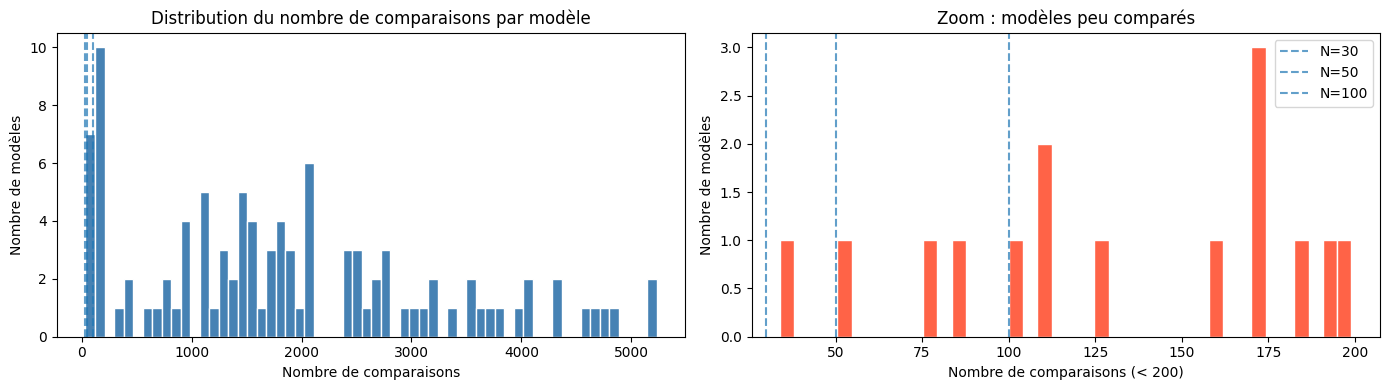

Total modèles : 101
  N ≥  30 → 101 modèles conservés
  N ≥  50 → 100 modèles conservés
  N ≥ 100 → 97 modèles conservés


In [6]:
import matplotlib.pyplot as plt

# Construction d'une matrice temporaire sur tout le dataset (sans seuil)
W_raw, models_raw = build_win_matrix(df_votes_no_ex_aequo)
total_games_raw = W_raw.sum(axis=1) + W_raw.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution complète
axes[0].hist(total_games_raw, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Nombre de comparaisons")
axes[0].set_ylabel("Nombre de modèles")
axes[0].set_title("Distribution du nombre de comparaisons par modèle")

# Zoom sur la queue gauche (modèles peu représentés)
axes[1].hist(total_games_raw[total_games_raw < 200], bins=40, color='tomato', edgecolor='white')
axes[1].set_xlabel("Nombre de comparaisons (< 200)")
axes[1].set_ylabel("Nombre de modèles")
axes[1].set_title("Zoom : modèles peu comparés")

# Seuils candidats
for ax in axes:
    for thresh in [30, 50, 100]:
        ax.axvline(thresh, linestyle='--', alpha=0.7, label=f'N={thresh}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Résumé du nombre de modèles conservés pour chaque seuil
print(f"Total modèles : {len(models_raw)}")
for thresh in [30, 50, 100]:
    n_kept = (total_games_raw >= thresh).sum()
    print(f"  N ≥ {thresh:3d} → {n_kept} modèles conservés")


On choisit **N = 50** : ce seuil élimine les modèles trop peu comparés (estimations instables) 
tout en conservant un nombre suffisant de modèles pour un classement significatif.

### c. Estimation des paramètres β par MLE (algorithme de Zermelo)

In [7]:
def bradley_terry_mle(W, tol=1e-8, max_iter=10_000):
    """
    Estime les paramètres β du modèle Bradley-Terry par l'algorithme
    de Zermelo (itération de point fixe, aussi appelé MM-algorithm).

    Mise à jour à chaque itération :
        β_i  ←  w_i  /  Σ_j  n_ij / (β_i + β_j)

    où  w_i   = nombre total de victoires du modèle i
         n_ij  = W[i,j] + W[j,i]  (total de confrontations entre i et j)

    Les β sont normalisés à chaque pas (somme = 1) pour assurer l'unicité.

    Paramètres
    ----------
    W        : matrice de gains (n x n)
    tol      : critère de convergence (norme L1 entre deux itérations)
    max_iter : nombre maximum d'itérations

    Retourne
    --------
    beta : np.ndarray (n,), paramètres de force estimés
    """
    n = W.shape[0]

    # --- Nombre total de confrontations entre chaque paire (i, j) ---
    N = W + W.T   # n_ij = W[i,j] + W[j,i]

    # --- Nombre total de victoires de chaque modèle ---
    wins = W.sum(axis=1)   # w_i

    # --- Initialisation uniforme ---
    beta = np.ones(n) / n

    for iteration in range(max_iter):
        beta_old = beta.copy()

        # Dénominateur : Σ_j  n_ij / (β_i + β_j)  pour chaque i
        # On vectorise : denom[i] = Σ_j N[i,j] / (beta[i] + beta[j])
        beta_sum = beta[:, None] + beta[None, :]   # matrice (n x n)
        # Éviter division par zéro (paires jamais confrontées : N[i,j]=0)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(N > 0, N / beta_sum, 0.0)
        denom = ratio.sum(axis=1)

        # Mise à jour de β
        beta = np.where(denom > 0, wins / denom, 0.0)

        # Normalisation (unicité de la solution à une constante multiplicative près)
        total = beta.sum()
        if total > 0:
            beta /= total

        # Critère de convergence
        if np.abs(beta - beta_old).sum() < tol:
            print(f"Convergence atteinte à l'itération {iteration + 1}")
            break
    else:
        print(f"Attention : pas de convergence après {max_iter} itérations")

    return beta


def compute_ranking(W, models, N_min=50):
    """
    Pipeline complet :
      1. Filtrage des modèles sous le seuil
      2. Estimation des β par BT-MLE
      3. Retour d'un DataFrame classé par β décroissant
    """
    W_f, models_f = filter_min_comparisons(W, models, N_min)
    print(f"  → {len(models_f)} modèles retenus (N ≥ {N_min})")

    beta = bradley_terry_mle(W_f)

    df_rank = pd.DataFrame({'model': models_f, 'beta': beta})
    df_rank = df_rank.sort_values('beta', ascending=False).reset_index(drop=True)
    df_rank['rank'] = df_rank.index + 1
    return df_rank


### d. Classement global (tous les votes)

In [8]:
N_MIN = 50   # seuil empirique déterminé ci-dessus

print("=== Classement GLOBAL ===")
W_global, models_global = build_win_matrix(df_votes_no_ex_aequo)
df_rank_global = compute_ranking(W_global, models_global, N_min=N_MIN)

print("\nTop 15 modèles (classement global) :")
display(df_rank_global.head(15))


=== Classement GLOBAL ===
  → 100 modèles retenus (N ≥ 50)
Convergence atteinte à l'itération 142

Top 15 modèles (classement global) :


,model,beta,rank
0,gemini-3.1-flash-lite-preview,0.030507,1
1,mistral-medium-3.1,0.023187,2
2,mistral-large-2512,0.021961,3
3,gpt-5.4,0.021957,4
4,mistral-medium-2508,0.021591,5
5,gemini-3-flash-preview,0.021296,6
6,gemini-2.5-flash,0.020608,7
7,magistral-medium,0.018186,8
8,qwen3-max-2025-09-23,0.018066,9
9,gemini-3.1-pro-preview,0.017245,10


### e. Classement créativité (conversations créatives uniquement)

In [9]:
# Filtre : au moins l'une des deux conversations étiquetée comme créative
df_votes_creative = df_votes_no_ex_aequo[
    df_votes_no_ex_aequo['conv_creative_a'] | df_votes_no_ex_aequo['conv_creative_b']
].copy()

print(f"Votes créatifs : {len(df_votes_creative):,} / {len(df_votes_no_ex_aequo):,} "
      f"({100 * len(df_votes_creative) / len(df_votes_no_ex_aequo):.1f}%)")

print("\n=== Classement CRÉATIVITÉ ===")
W_creative, models_creative = build_win_matrix(df_votes_creative)
df_rank_creative = compute_ranking(W_creative, models_creative, N_min=N_MIN)

print("\nTop 15 modèles (classement créativité) :")
display(df_rank_creative.head(15))


Votes créatifs : 7,580 / 94,939 (8.0%)

=== Classement CRÉATIVITÉ ===
  → 75 modèles retenus (N ≥ 50)
Convergence atteinte à l'itération 202

Top 15 modèles (classement créativité) :


,model,beta,rank
0,mistral-medium-2508,0.044377,1
1,qwen3-max-2025-09-23,0.035538,2
2,mistral-large-2512,0.034789,3
3,gemini-3-pro-preview,0.029686,4
4,deepseek-chat-v3.1,0.029502,5
5,gemini-3-flash-preview,0.028515,6
6,DeepSeek-V3.2,0.027484,7
7,Qwen3-Coder-480B-A35B-Instruct,0.026628,8
8,gemini-2.5-flash,0.026526,9
9,gemini-2.0-flash,0.025271,10


### f. Comparaison des deux classements (Spearman ρ + scatter plot)

In [10]:
from scipy.stats import spearmanr

# --- Jointure sur les modèles présents dans LES DEUX classements ---
df_merged = df_rank_global[['model', 'rank']].rename(columns={'rank': 'rank_global'}).merge(
    df_rank_creative[['model', 'rank']].rename(columns={'rank': 'rank_creative'}),
    on='model'
)

print(f"Modèles communs aux deux classements : {len(df_merged)}")

# --- Corrélation de Spearman ---
rho, pval = spearmanr(df_merged['rank_global'], df_merged['rank_creative'])
print(f"Corrélation de Spearman ρ = {rho:.3f}  (p = {pval:.2e})")


Modèles communs aux deux classements : 75
Corrélation de Spearman ρ = 0.874  (p = 1.51e-24)


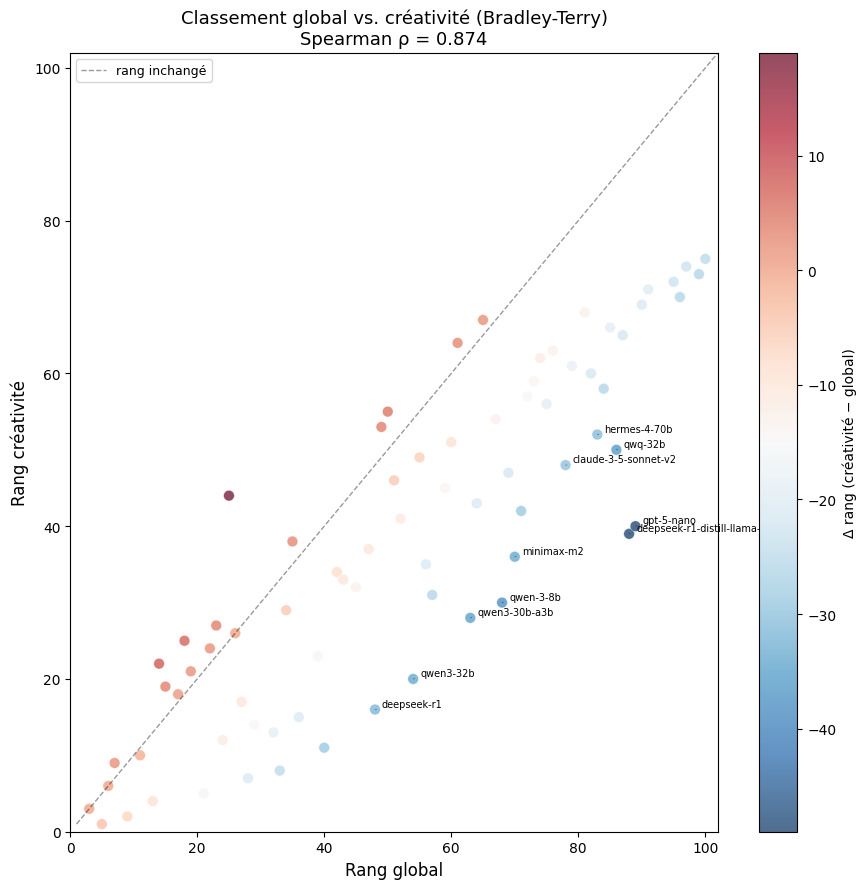


Modèles avec les plus grands écarts de classement :


,model,rank_global,rank_creative,rank_diff
0,deepseek-r1-distill-llama-70b,88,39,-49
1,gpt-5-nano,89,40,-49
2,qwen-3-8b,68,30,-38
3,qwq-32b,86,50,-36
4,qwen3-30b-a3b,63,28,-35
5,qwen3-32b,54,20,-34
6,minimax-m2,70,36,-34
7,deepseek-r1,48,16,-32
8,hermes-4-70b,83,52,-31
9,claude-3-5-sonnet-v2,78,48,-30


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))

# Écart de rang (absolu) pour identifier les modèles qui bougent le plus
df_merged['rank_diff'] = df_merged['rank_creative'] - df_merged['rank_global']
df_merged['abs_diff']  = df_merged['rank_diff'].abs()

# Seuil pour annoter : top 10 des modèles avec le plus grand mouvement
threshold = df_merged['abs_diff'].nlargest(10).min()

# Scatter : couleur = direction du mouvement
scatter = ax.scatter(
    df_merged['rank_global'],
    df_merged['rank_creative'],
    c=df_merged['rank_diff'],        # positif = monte en créativité
    cmap='RdBu_r',
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.4
)
plt.colorbar(scatter, ax=ax, label='Δ rang (créativité − global)')

# Diagonale de référence (rang inchangé)
lim = max(df_merged[['rank_global', 'rank_creative']].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', lw=1, alpha=0.4, label='rang inchangé')

# Annotations des modèles qui bougent le plus
for _, row in df_merged[df_merged['abs_diff'] >= threshold].iterrows():
    ax.annotate(
        row['model'],
        xy=(row['rank_global'], row['rank_creative']),
        fontsize=7,
        xytext=(5, 2),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Rang global", fontsize=12)
ax.set_ylabel("Rang créativité", fontsize=12)
ax.set_title(
    f"Classement global vs. créativité (Bradley-Terry)\nSpearman ρ = {rho:.3f}",
    fontsize=13
)
ax.legend(fontsize=9)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

# --- Tableau des modèles avec le plus grand écart ---
print("\nModèles avec les plus grands écarts de classement :")
display(
    df_merged.sort_values('abs_diff', ascending=False)
             .head(15)[['model', 'rank_global', 'rank_creative', 'rank_diff']]
             .reset_index(drop=True)
)
